In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [4]:
print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


In [5]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [6]:
x_train = x_train.astype('float32') / 255.0

In [7]:
x_test = x_test.astype('float32') / 255.0

In [8]:
x_train = x_train.reshape((x_train.shape[0], 28, 28, 1))
x_test = x_test.reshape((x_test.shape[0], 28, 28, 1))

print(f"x_train shape after normalization and reshape: {x_train.shape}")
print(f"x_test shape after normalization and reshape: {x_test.shape}")


x_train shape after normalization and reshape: (60000, 28, 28, 1)
x_test shape after normalization and reshape: (10000, 28, 28, 1)


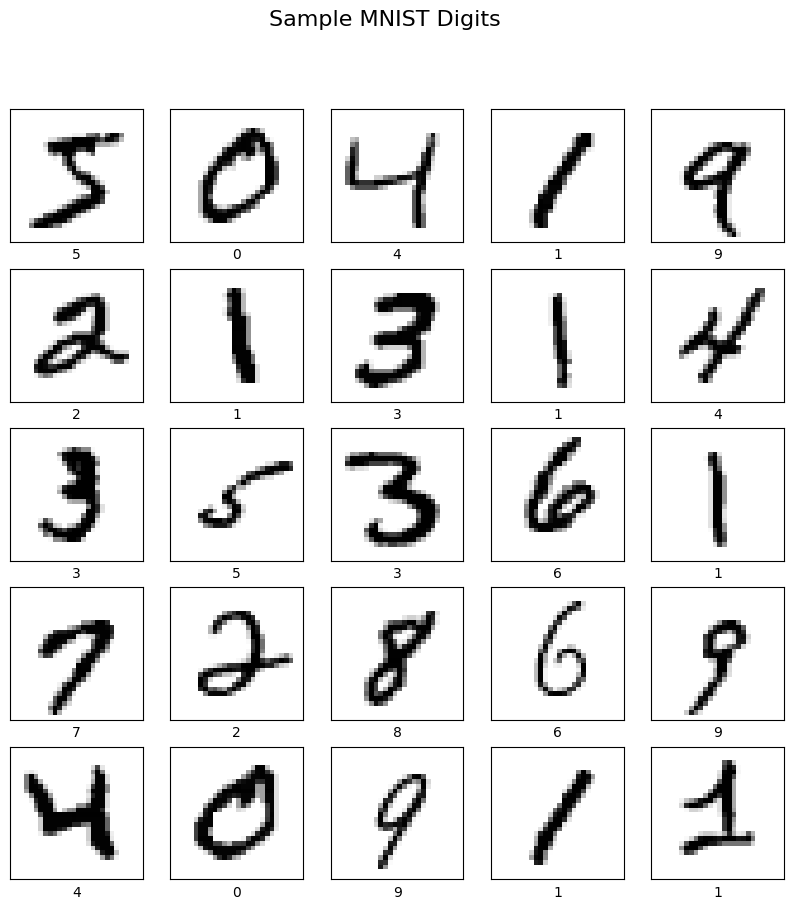

In [9]:
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(y_train[i])
plt.suptitle('Sample MNIST Digits', fontsize=16)
plt.show()

In [10]:
def init_weights(shape):
    return tf.Variable(tf.random.truncated_normal(shape, stddev=0.1))

def init_bias(shape):
    return tf.Variable(tf.constant(0.1, shape=shape))

def conv2d(x, W):
    return tf.nn.conv2d(x, W, strides=[1, 1, 1, 1], padding='SAME')

def max_pool_2x2(x):
    return tf.nn.max_pool(x, ksize=[1, 2, 2, 1], strides=[1, 2, 2, 1], padding='SAME')

W_conv1 = init_weights([5, 5, 1, 32])
b_conv1 = init_bias([32])
W_conv2 = init_weights([5, 5, 32, 64])
b_conv2 = init_bias([64])
W_fc1 = init_weights([7 * 7 * 64, 1024])
b_fc1 = init_bias([1024])
W_fc2 = init_weights([1024, 10])
b_fc2 = init_bias([10])

def forward_pass(x):
    h_conv1 = tf.nn.relu(conv2d(x, W_conv1) + b_conv1)
    h_pool1 = max_pool_2x2(h_conv1)
    h_conv2 = tf.nn.relu(conv2d(h_pool1, W_conv2) + b_conv2)
    h_pool2 = max_pool_2x2(h_conv2)
    h_pool2_flat = tf.reshape(h_pool2, [-1, 7 * 7 * 64])
    h_fc1 = tf.nn.relu(tf.matmul(h_pool2_flat, W_fc1) + b_fc1)
    logits = tf.matmul(h_fc1, W_fc2) + b_fc2
    return logits

print("Model initialized using TensorFlow low-level API.")

Model initialized using TensorFlow low-level API.
